In [1]:
import pandas as pd
import numpy as np 
import seaborn as sns

from scipy.stats import gaussian_kde 

from scipy.stats import entropy
import matplotlib.pyplot as plt
from tqdm import tqdm




import os

#### About directories

In [2]:
print(os.getcwd())
print(print("\n",os.listdir()))

/home/shaikh/Desktop/PythonVSCode/20250301_ML_Ops/20260125 - BongoDevMLOPS/20260311_MachineLearning

 ['ml03env', 'requirements.txt', '20241215_ML', '.git', 'test.txt', 'DecisionTree.ipynb', 'RndomForest.ipynb', 'diabetes_decision_tree', 'main.py', 'housing_single_feature.csv', 'diabetes.csv', 'test.ipynb', 'LoisticsRegression.ipynb', 'knn.ipynb']
None


In [3]:
root_dir = os.getcwd()

### read diabetes.csv file from adding root_dir location

file_path = os.path.join(root_dir,'housing_single_feature.csv')

df = pd.read_csv(file_path)

display(df.head())

,area,price
0,7420,13300000
1,8960,12250000
2,9960,12250000
3,7500,12215000
4,7420,11410000


#### Simple Linear Regression

,area,price
0,425.09,63937.89
1,309.86,45880.56
2,353.60,53223.70
3,380.27,53065.11
4,468.80,69880.10


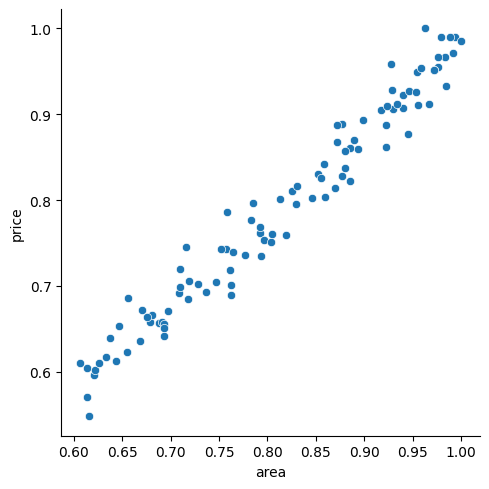

In [4]:
## Create Data Set 


np.random.seed(42)
n_samples = 100

area = np.random.uniform(500, 300, n_samples)
price= (150*area) + np.random.normal(0, 2000, n_samples)


house_dataset = pd.DataFrame(
    
{    'area':area,
    'price':price}
       
).round(2)

display(house_dataset.head())




#### Normalize Data Set 

house_dataset = house_dataset/house_dataset.max()



#### Plot Data

sns.relplot(
    data = house_dataset,
    x = 'area',
    y = 'price'    
    
)



Weight: 0.37
Bias: 0.95


,area,price,price_pred_rand
0,0.852055,0.830402,1.269843
1,0.621086,0.595880,1.183336
2,0.708759,0.691250,1.216173
3,0.762217,0.689190,1.236195
4,0.939667,0.907577,1.302657


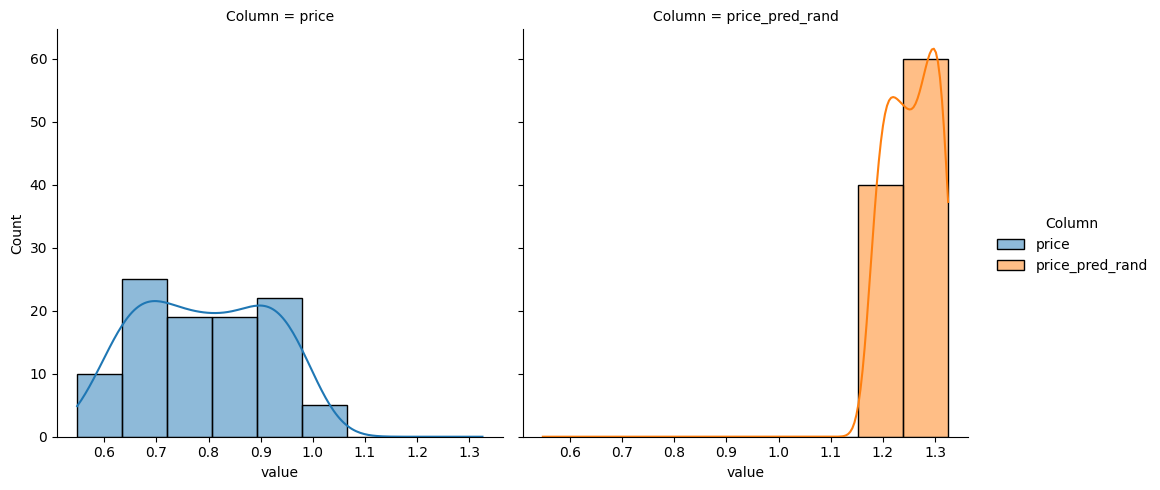

In [5]:
np.random.seed(42)


def get_house_price (x,w,b ):
    y_pred = w*x +b
    return y_pred


w = np.random.uniform(0, 1)
b = np.random.uniform(0, 1)
print(f"Weight: {w:.2f}\nBias: {b:.2f}")
house_dataset['price_pred_rand']= get_house_price(house_dataset['area'],w,b)
display(house_dataset.head())



### Distribution plot

sns.displot(
    
    data=house_dataset.melt(value_vars=['price', 'price_pred_rand'], var_name='Column'),
    x='value', 
    col='Column',
    kind='hist',
    kde=True,
    hue='Column',
    palette=['#1f77b4', '#ff7f0e']
    
)


In [6]:
###### KL Divergence : Dissimilarites Between Distributions



from scipy.stats import gaussian_kde

def kl_divergence(p_data, q_data, n_points=1000, epsilon=1e-10):
    p_data = np.array(p_data).flatten()
    q_data = np.array(q_data).flatten()
    p_data = p_data[~np.isnan(p_data)]
    q_data = q_data[~np.isnan(q_data)]
    if len(p_data) == 0 or len(q_data) == 0:
        return np.nan    
    all_data = np.concatenate([p_data, q_data])
    support = np.linspace(all_data.min(), all_data.max(), n_points)
    kde_p = gaussian_kde(p_data)
    kde_q = gaussian_kde(q_data)
    p = kde_p(support)
    q = kde_q(support)
    p = np.clip(p, epsilon, None)
    q = np.clip(q, epsilon, None)
    p /= p.sum()
    q /= q.sum()
    kl = np.sum(p * np.log(p / q))
    return kl

kl_value = kl_divergence(
    house_dataset['price'],
    house_dataset['price_pred_rand']
)
print(f"KL(price || price_pred_rand) = {kl_value:.4f}")


KL(price || price_pred_rand) = 23.6387


In [7]:
def cost_function(x, y_true, w, b):
    y_pred = get_house_price(x, w, b)
    mse = np.sum((y_true - y_pred) ** 2) / len(y_true)
    return mse


X = house_dataset['area']
y_true = house_dataset['price']

loss = cost_function(X, y_true, w, b)
print(f'loss:  {loss: .2f}')

loss:   0.22


In [8]:
loss_1 = cost_function(X, y_true, w=100, b=125)
print(loss_1)

loss_2 = cost_function(X, y_true, w=124, b=189)
print(loss_2)

loss_3 = cost_function(X, y_true, w=112, b=169)
print(loss_3)

42401.51579551217
83797.69855892114
67433.5897076277


In [9]:
""" ML model's objective is to reduce loss / cost function.
"""
weights = np.linspace(-10, 10, 100)
biases = np.linspace(-10, 10, 100)
weights_mesh, biases_mesh = np.meshgrid(weights, biases)

""" We will produce 100,00 points
Each point: (w, b, loss)
"""
losses_mesh = []
for w in tqdm(np.ravel(weights_mesh[0])):
    for b in np.ravel(biases_mesh[0]):
        loss = cost_function(X, y_true, w, b)        
        losses_mesh.append(loss)
        
losses_mesh = np.array(losses_mesh)
losses_mesh = losses_mesh.reshape(weights_mesh.shape)

100%|██████████| 100/100 [00:02<00:00, 36.12it/s]


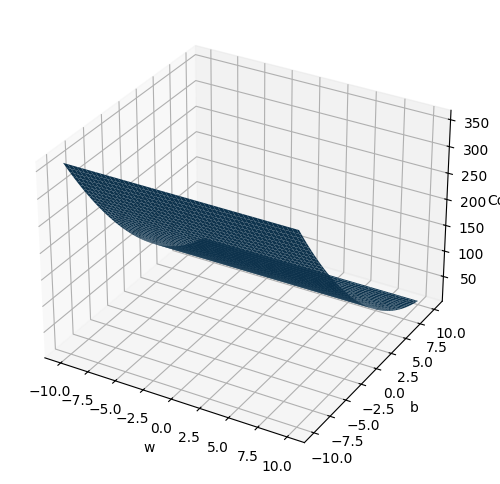

In [10]:
fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(weights_mesh, biases_mesh, losses_mesh)
ax.set_xlabel('w')
ax.set_ylabel('b')
ax.set_zlabel('Cost')
plt.show()

In [11]:
""" Gradient Descent
"""
def compute_gradient(X, y_true, w, b):
    delta=0.001
    cost1 = cost_function(X, y_true, w, b)
    cost2 = cost_function(X, y_true, w + delta, b)
    cost3 = cost_function(X, y_true, w, b + delta)
    dw = (cost2 - cost1) / delta
    db = (cost3 - cost1) / delta
    return dw, db


w = np.random.uniform(0, 1)
b = np.random.uniform(0, 1)


loss = cost_function(X, y_true, w, b)
print(loss)

0.16433770023877975


In [12]:
""" calculate gradient """
dw, db = compute_gradient(X, y_true, w, b)
print(dw, db)

0.6496638665655086 0.8078931163508773


In [13]:
learning_rate = 0.01
w = w - learning_rate * dw
b = b - learning_rate * db




""" Weight update 
If dw = -0.25 then w = w - (-0.25) = w + 0.25 
If dw = 0.25 then w = w - 0.25 = w - 0.25
"""
learning_rate = 0.01
w = w - learning_rate * dw
b = b - learning_rate * db




"""lr=0.01, loss=0.58, next loss=0.55, change=0.03
   lr=0.0001, loss=0.086838, next loss=0.086810, change=0.00028
   lr=1.5, loss=0.187, next loss=1.59, negative change
"""
loss = cost_function(X, y_true, w, b)
print(loss)




for epoch in range(1000):
    # Calculate logits
    loss = cost_function(X, y_true, w, b)
    # Calculate the gradients
    dw, db = compute_gradient(X, y_true, w, b)
    
    # Update weights
    w = w - learning_rate * dw
    b = b - learning_rate * db
    
    if epoch % 100 == 0:
        print(loss)


print(w, b)




0.14358446451179357
0.14358446451179357
0.0036627170328054413
0.0034158018994667988
0.003319568335356134
0.0032263663090062473
0.0031362655477348645
0.0030491741187782823
0.0029649921786928622
0.0028836228295051865
0.0028049723833703526
0.6082725633258999 0.2981459841057881


,area,price,price_pred_rand,price_pred_learned
0,0.852055,0.830402,1.269843,0.816427
1,0.621086,0.595880,1.183336,0.675936
2,0.708759,0.691250,1.216173,0.729265
3,0.762217,0.689190,1.236195,0.761782
4,0.939667,0.907577,1.302657,0.869720


Bedore value:  23.639
After value:  0.674


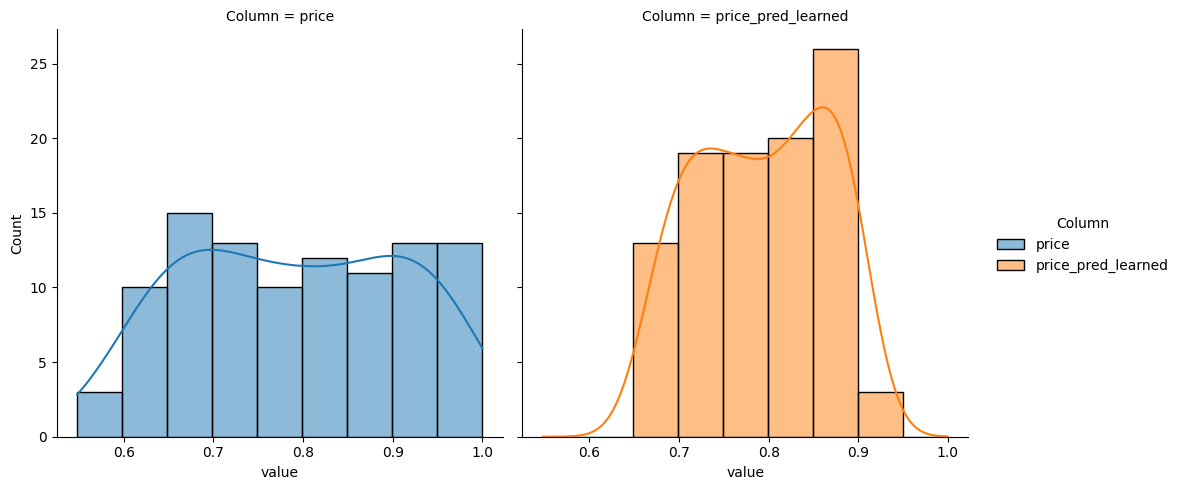

In [14]:
house_dataset["price_pred_learned"] = get_house_price(house_dataset["area"], w, b)
display(house_dataset.head())

sns.displot(
    data=house_dataset.melt(value_vars=['price', 'price_pred_learned'], var_name='Column'),
    x='value',
    col='Column',
    kind='hist',
    kde=True,
    hue='Column',
    palette=['#1f77b4', '#ff7f0e']
)


kl_value_before = kl_divergence(house_dataset['price'], house_dataset['price_pred_rand']) 
kl_value_after = kl_divergence(house_dataset['price'], house_dataset['price_pred_learned']) 

print(f"Bedore value: {kl_value_before: .3f}")
print(f"After value: {kl_value_after: .3f}")

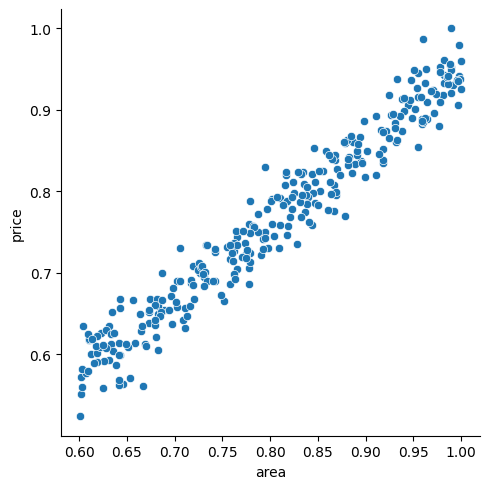

In [15]:

####### Create Data Set

np.random.seed(43)

sample_size = 300

area = np.random.uniform(300, 500, sample_size)
price = (area*150) + (np.random.normal(0, 2000, sample_size))


housing_data = pd.DataFrame(
    
    {'area':area, "price":price}
    
).round(2)


housing_data.head()



####### Normalize Data Set


housing_data = housing_data/housing_data.max()


####### Create Data Set


sns.relplot(
    data = housing_data,
    x = 'area',
    y = 'price'
    
)

